In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 19: Feature Distribution Diagnostics

**Objective:** Diagnose whether the handcrafted candidate features actually separate oracle-good candidates from oracle-bad candidates.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- rebuild the consolidated candidate table used in previous chapters
- label candidates as oracle-good or oracle-bad
- compare feature distributions between the two groups
- measure feature separation using standardized mean difference
- identify whether ranking failure is caused by weak feature separation

# 🧠 Background Theory

Chapters 16–18 showed that candidate ranking is the main bottleneck.

Raw LoG + NMS contains GT-near candidates, but the learned rankers do not place those candidates near the top of the ranked list.

This chapter asks a more basic question:

> Do oracle-good and oracle-bad candidates look different in the current handcrafted feature space?

If the distributions overlap heavily, then the ranking model may be failing because the features are not strong enough.

# 📚 New Vocabulary

## Oracle-Good Candidate
A candidate whose nearest GT centroid is within the match radius.

## Oracle-Bad Candidate
A candidate whose nearest GT centroid is outside the match radius.

## Feature Distribution
The spread of values a feature takes across a group of candidates.

## Standardized Mean Difference
A scale-normalized measure of separation between two groups.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.2 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Ground Truth

I will continue using sample `44b6_12dfb391` so this chapter can be compared directly with the earlier ranking experiments.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

volume = zarr.open(zarr_path, mode="r")
image = volume["0"]   # shape: (T, Z, Y, X)

geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 2 — Define Detection, NMS, Distance, and Feature Helpers

This notebook uses the same LoG + NMS candidate pipeline from Chapters 16–18.

In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
def add_center_intensity(frame_3d, pred_df):
    pred_df = pred_df.copy()
    intensities = []

    Z, Y, X = frame_3d.shape

    for _, row in pred_df.iterrows():
        z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
        z = np.clip(z, 0, Z - 1)
        y = np.clip(y, 0, Y - 1)
        x = np.clip(x, 0, X - 1)

        intensities.append(float(frame_3d[z, y, x]))

    pred_df["center_intensity"] = intensities
    return pred_df

In [8]:
def consolidate_candidates_3d(pred_df, radius=3.0, score_col="center_intensity"):
    if len(pred_df) == 0:
        return pred_df.copy()

    work_df = pred_df.copy().sort_values(score_col, ascending=False).reset_index(drop=True)
    kept_rows = []

    while len(work_df) > 0:
        keep = work_df.iloc[0]
        kept_rows.append(keep)

        keep_point = np.array([keep["z"], keep["y"], keep["x"]], dtype=float)
        other_points = work_df[["z", "y", "x"]].to_numpy(dtype=float)

        dists = np.sqrt(((other_points - keep_point) ** 2).sum(axis=1))
        work_df = work_df[dists > radius].reset_index(drop=True)

    return pd.DataFrame(kept_rows).reset_index(drop=True)

In [9]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    return np.sqrt(((gt - pred) ** 2).sum(axis=2))

In [10]:
def extract_candidate_features(frame_3d, detections_df, patch_radius=4):
    rows = []
    z_max, y_max, x_max = frame_3d.shape

    for _, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z].astype(np.float32)

        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1]

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        max_idx = np.unravel_index(np.argmax(patch), patch.shape)
        max_y_patch, max_x_patch = max_idx
        patch_center_y = y - y0
        patch_center_x = x - x0

        center_to_patch_max_dist = float(
            np.sqrt((max_y_patch - patch_center_y) ** 2 + (max_x_patch - patch_center_x) ** 2)
        )

        yy, xx = np.indices(patch.shape)
        patch_sum = patch.sum()

        if patch_sum > 0:
            com_y = float((yy * patch).sum() / patch_sum)
            com_x = float((xx * patch).sum() / patch_sum)
            patch_com_offset = float(
                np.sqrt((com_y - patch_center_y) ** 2 + (com_x - patch_center_x) ** 2)
            )
        else:
            patch_com_offset = np.nan

        border_margin = min(y, x, y_max - 1 - y, x_max - 1 - x)
        is_near_border = int(border_margin < patch_radius)

        z_vals_local = []
        for zz in [z - 1, z, z + 1]:
            if 0 <= zz < z_max:
                z_vals_local.append(float(frame_3d[zz, y, x]))

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": float(row["sigma"]),
            "nearest_gt_dist": float(row["nearest_gt_dist"]),
            "oracle_good": bool(row["oracle_good"]),

            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,

            "z_center_intensity": float(frame_3d[z, y, x]),
            "z_support_mean": float(np.mean(z_vals_local)),
            "z_support_std": float(np.std(z_vals_local)),
            "z_support_min": float(np.min(z_vals_local)),
            "z_support_max": float(np.max(z_vals_local)),
        })

    return pd.DataFrame(rows)

# Step 3 — Build the Consolidated Candidate Table

I will build one candidate table from multiple timepoints.

Each candidate will receive:
- coordinates
- nearest GT distance
- oracle-good label
- handcrafted features

In [11]:
analysis_timepoints = [0, 8, 20, 40, 60, 80]

nms_radius = 3.0
match_radius = 6

candidate_tables = []

for t in analysis_timepoints:
    frame_t = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points_t = gt_nodes_t[["z", "y", "x"]].to_numpy()

    raw_t = detect_blobs_log_3d_slicewise(frame_t)
    raw_t = add_center_intensity(frame_t, raw_t)

    nms_t = consolidate_candidates_3d(
        raw_t,
        radius=nms_radius,
        score_col="center_intensity"
    )

    if len(nms_t) == 0 or len(gt_points_t) == 0:
        continue

    nms_points_t = nms_t[["z", "y", "x"]].to_numpy()
    dist_t = pairwise_distances_3d(gt_points_t, nms_points_t)

    nms_t["nearest_gt_dist"] = dist_t.min(axis=0)
    nms_t["oracle_good"] = nms_t["nearest_gt_dist"] <= match_radius

    features_t = extract_candidate_features(frame_t, nms_t, patch_radius=4)
    features_t["t"] = t

    candidate_tables.append(features_t)

candidate_df = pd.concat(candidate_tables, ignore_index=True)

print("Candidate rows:", len(candidate_df))
print(candidate_df["oracle_good"].value_counts())
candidate_df.head()

Candidate rows: 4405
oracle_good
False    4337
True       68
Name: count, dtype: int64


,z,y,x,sigma,nearest_gt_dist,oracle_good,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,z_center_intensity,z_support_mean,z_support_std,z_support_min,z_support_max,t
0,53,82,255,3.5,71.561163,False,3517.0,2713.933350,3517.0,532.094055,803.066650,0.0,1.909732,1,3517.0,3255.333333,350.440041,2760.0,3517.0,0
1,48,86,128,3.5,41.821047,False,3140.0,2135.111084,3140.0,671.388611,1004.888916,0.0,0.203683,0,3140.0,2910.333333,238.246837,2582.0,3140.0,0
2,52,127,214,3.5,72.594766,False,3087.0,2504.913574,3135.0,411.433014,582.086426,2.0,0.107216,0,3087.0,2897.000000,145.370790,2734.0,3087.0,0
3,44,109,108,3.0,28.705400,False,2900.0,2070.814697,3029.0,610.202087,829.185303,1.0,0.218143,0,2900.0,2672.666667,193.536101,2427.0,2900.0,0
4,52,92,197,3.5,36.249138,False,2897.0,2280.419678,2965.0,362.084930,616.580322,1.0,0.171821,0,2897.0,2677.666667,247.991039,2331.0,2897.0,0


# Step 4 — Check Class Balance

Before comparing features, I need to know how many oracle-good and oracle-bad candidates are in the table.

In [12]:
class_summary = pd.Series({
    "num_candidates": len(candidate_df),
    "num_oracle_good": int(candidate_df["oracle_good"].sum()),
    "num_oracle_bad": int((~candidate_df["oracle_good"]).sum()),
    "oracle_good_fraction": float(candidate_df["oracle_good"].mean())
})

class_summary

num_candidates          4405.000000
num_oracle_good           68.000000
num_oracle_bad          4337.000000
oracle_good_fraction       0.015437
dtype: float64

# Step 5 — Compare Feature Statistics by Class

I will compare each feature between oracle-good and oracle-bad candidates.

In [13]:
feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "z_center_intensity",
    "z_support_mean",
    "z_support_std",
    "z_support_min",
    "z_support_max",
]

good_df = candidate_df[candidate_df["oracle_good"]].copy()
bad_df = candidate_df[~candidate_df["oracle_good"]].copy()

feature_summary = candidate_df.groupby("oracle_good")[feature_cols].agg(
    ["mean", "median", "std"]
)

feature_summary

sigma                 center_intensity                      \
                 mean median      std             mean  median         std   
oracle_good                                                                  
False        3.468296    3.5  0.15102      1785.118515  1748.0  457.438673   
True         3.500000    3.5  0.00000      1735.294118  1657.5  369.406747   

              patch_mean                             patch_max  ...  \
                    mean       median         std         mean  ...   
oracle_good                                                     ...   
False        1540.043300  1515.567871  396.798792  1846.486973  ...   
True         1508.469068  1474.024719  305.750975  1795.720588  ...   

            z_support_mean z_support_std                        z_support_min  \
                       std          mean      median        std          mean   
oracle_good                                                                     
False           430.269985    135.442999  112.399091  86.616606   1519.321881   
True            345.156340    133.150986  103.765638  84.822151   1477.205882   

                                z_support_max                      
             median         std          mean  median         std  
oracle_good                                                        
False        1487.0  425.987076   1836.871109  1806.0  456.381484  
True         1410.5  323.074482   1789.441176  1799.0  382.381672  

[2 rows x 42 columns]

# Step 6 — Measure Feature Separation

I will calculate standardized mean difference for each feature.

A larger absolute value means stronger separation between oracle-good and oracle-bad candidates.

In [14]:
effect_rows = []

for feat in feature_cols:
    mean_good = good_df[feat].mean()
    mean_bad = bad_df[feat].mean()
    std_good = good_df[feat].std()
    std_bad = bad_df[feat].std()

    pooled_std = np.sqrt((std_good**2 + std_bad**2) / 2)

    if pooled_std == 0 or np.isnan(pooled_std):
        smd = np.nan
    else:
        smd = (mean_good - mean_bad) / pooled_std

    effect_rows.append({
        "feature": feat,
        "mean_good": mean_good,
        "mean_bad": mean_bad,
        "std_good": std_good,
        "std_bad": std_bad,
        "smd": smd,
        "abs_smd": abs(smd) if pd.notnull(smd) else np.nan
    })

effect_df = pd.DataFrame(effect_rows).sort_values("abs_smd", ascending=False)
effect_df

,feature,mean_good,mean_bad,std_good,std_bad,smd,abs_smd
8,is_near_border,0.014706,0.093844,0.121268,0.291645,-0.354336,0.354336
7,patch_com_offset,0.141982,0.270015,0.229348,0.495996,-0.331346,0.331346
0,sigma,3.500000,3.468296,0.000000,0.151020,0.296890,0.296890
5,local_contrast,226.825050,245.075215,97.813883,136.429001,-0.153747,0.153747
3,patch_max,1795.720588,1846.486973,365.589642,469.231997,-0.120696,0.120696
1,center_intensity,1735.294118,1785.118515,369.406747,457.438673,-0.119840,0.119840
9,z_center_intensity,1735.294118,1785.118515,369.406747,457.438673,-0.119840,0.119840
4,patch_std,175.952758,183.437087,49.033694,75.753826,-0.117294,0.117294
13,z_support_max,1789.441176,1836.871109,382.381672,456.381484,-0.112657,0.112657
12,z_support_min,1477.205882,1519.321881,323.074482,425.987076,-0.111404,0.111404


In [15]:
top_features = effect_df["feature"].head(6).tolist()
top_features

['is_near_border',
 'patch_com_offset',
 'sigma',
 'local_contrast',
 'patch_max',
 'center_intensity']

# Step 7 — Plot Top Feature Distributions

These plots show whether the strongest features actually separate oracle-good from oracle-bad candidates.

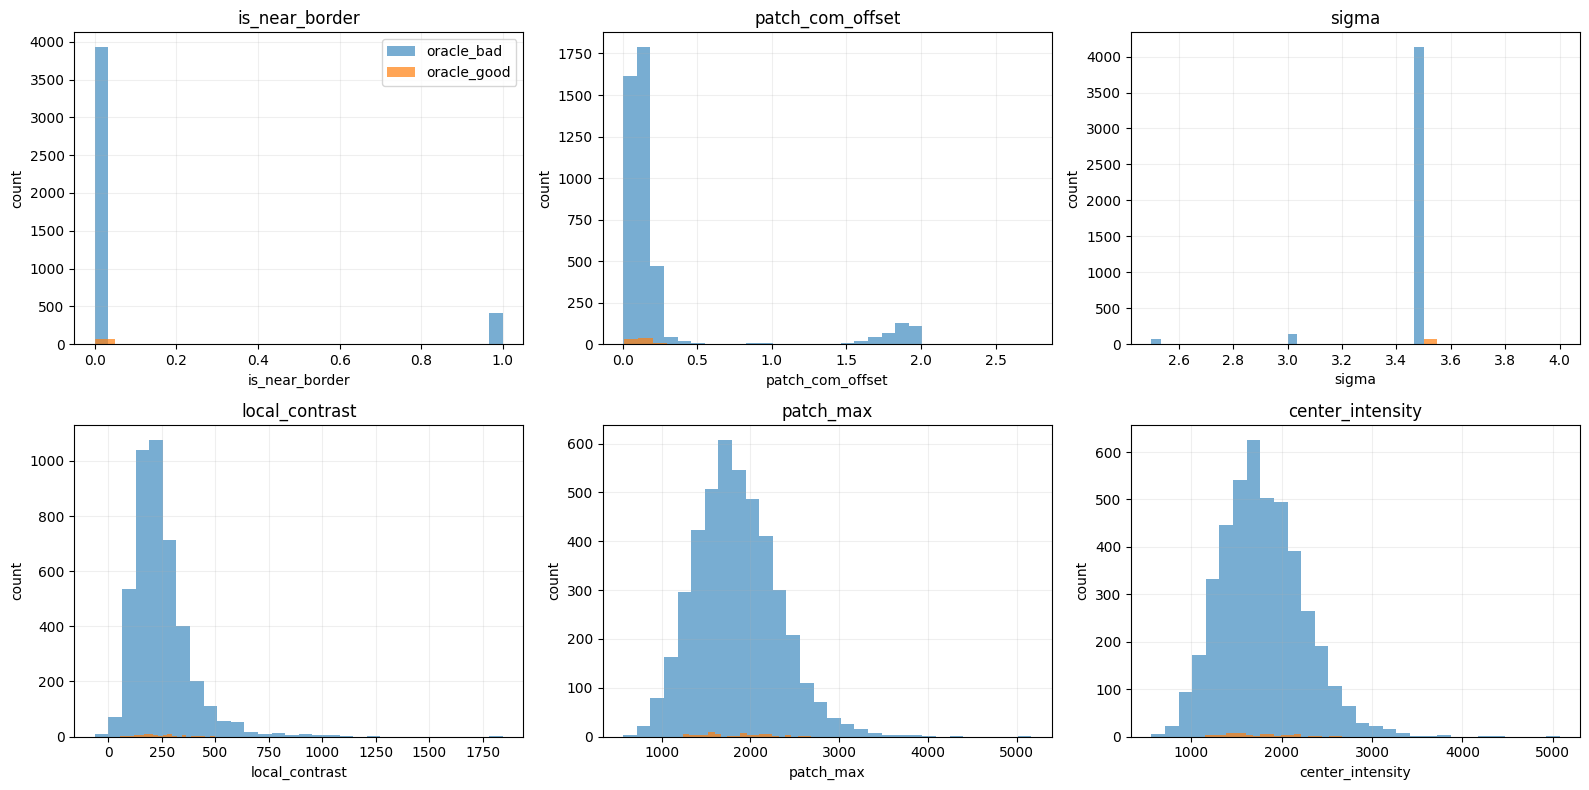

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, feat in zip(axes, top_features):
    ax.hist(
        bad_df[feat].dropna(),
        bins=30,
        alpha=0.6,
        label="oracle_bad"
    )
    ax.hist(
        good_df[feat].dropna(),
        bins=20,
        alpha=0.7,
        label="oracle_good"
    )

    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.2)

axes[0].legend()
plt.tight_layout()
plt.show()

# Step 8 — Plot All Feature Distributions

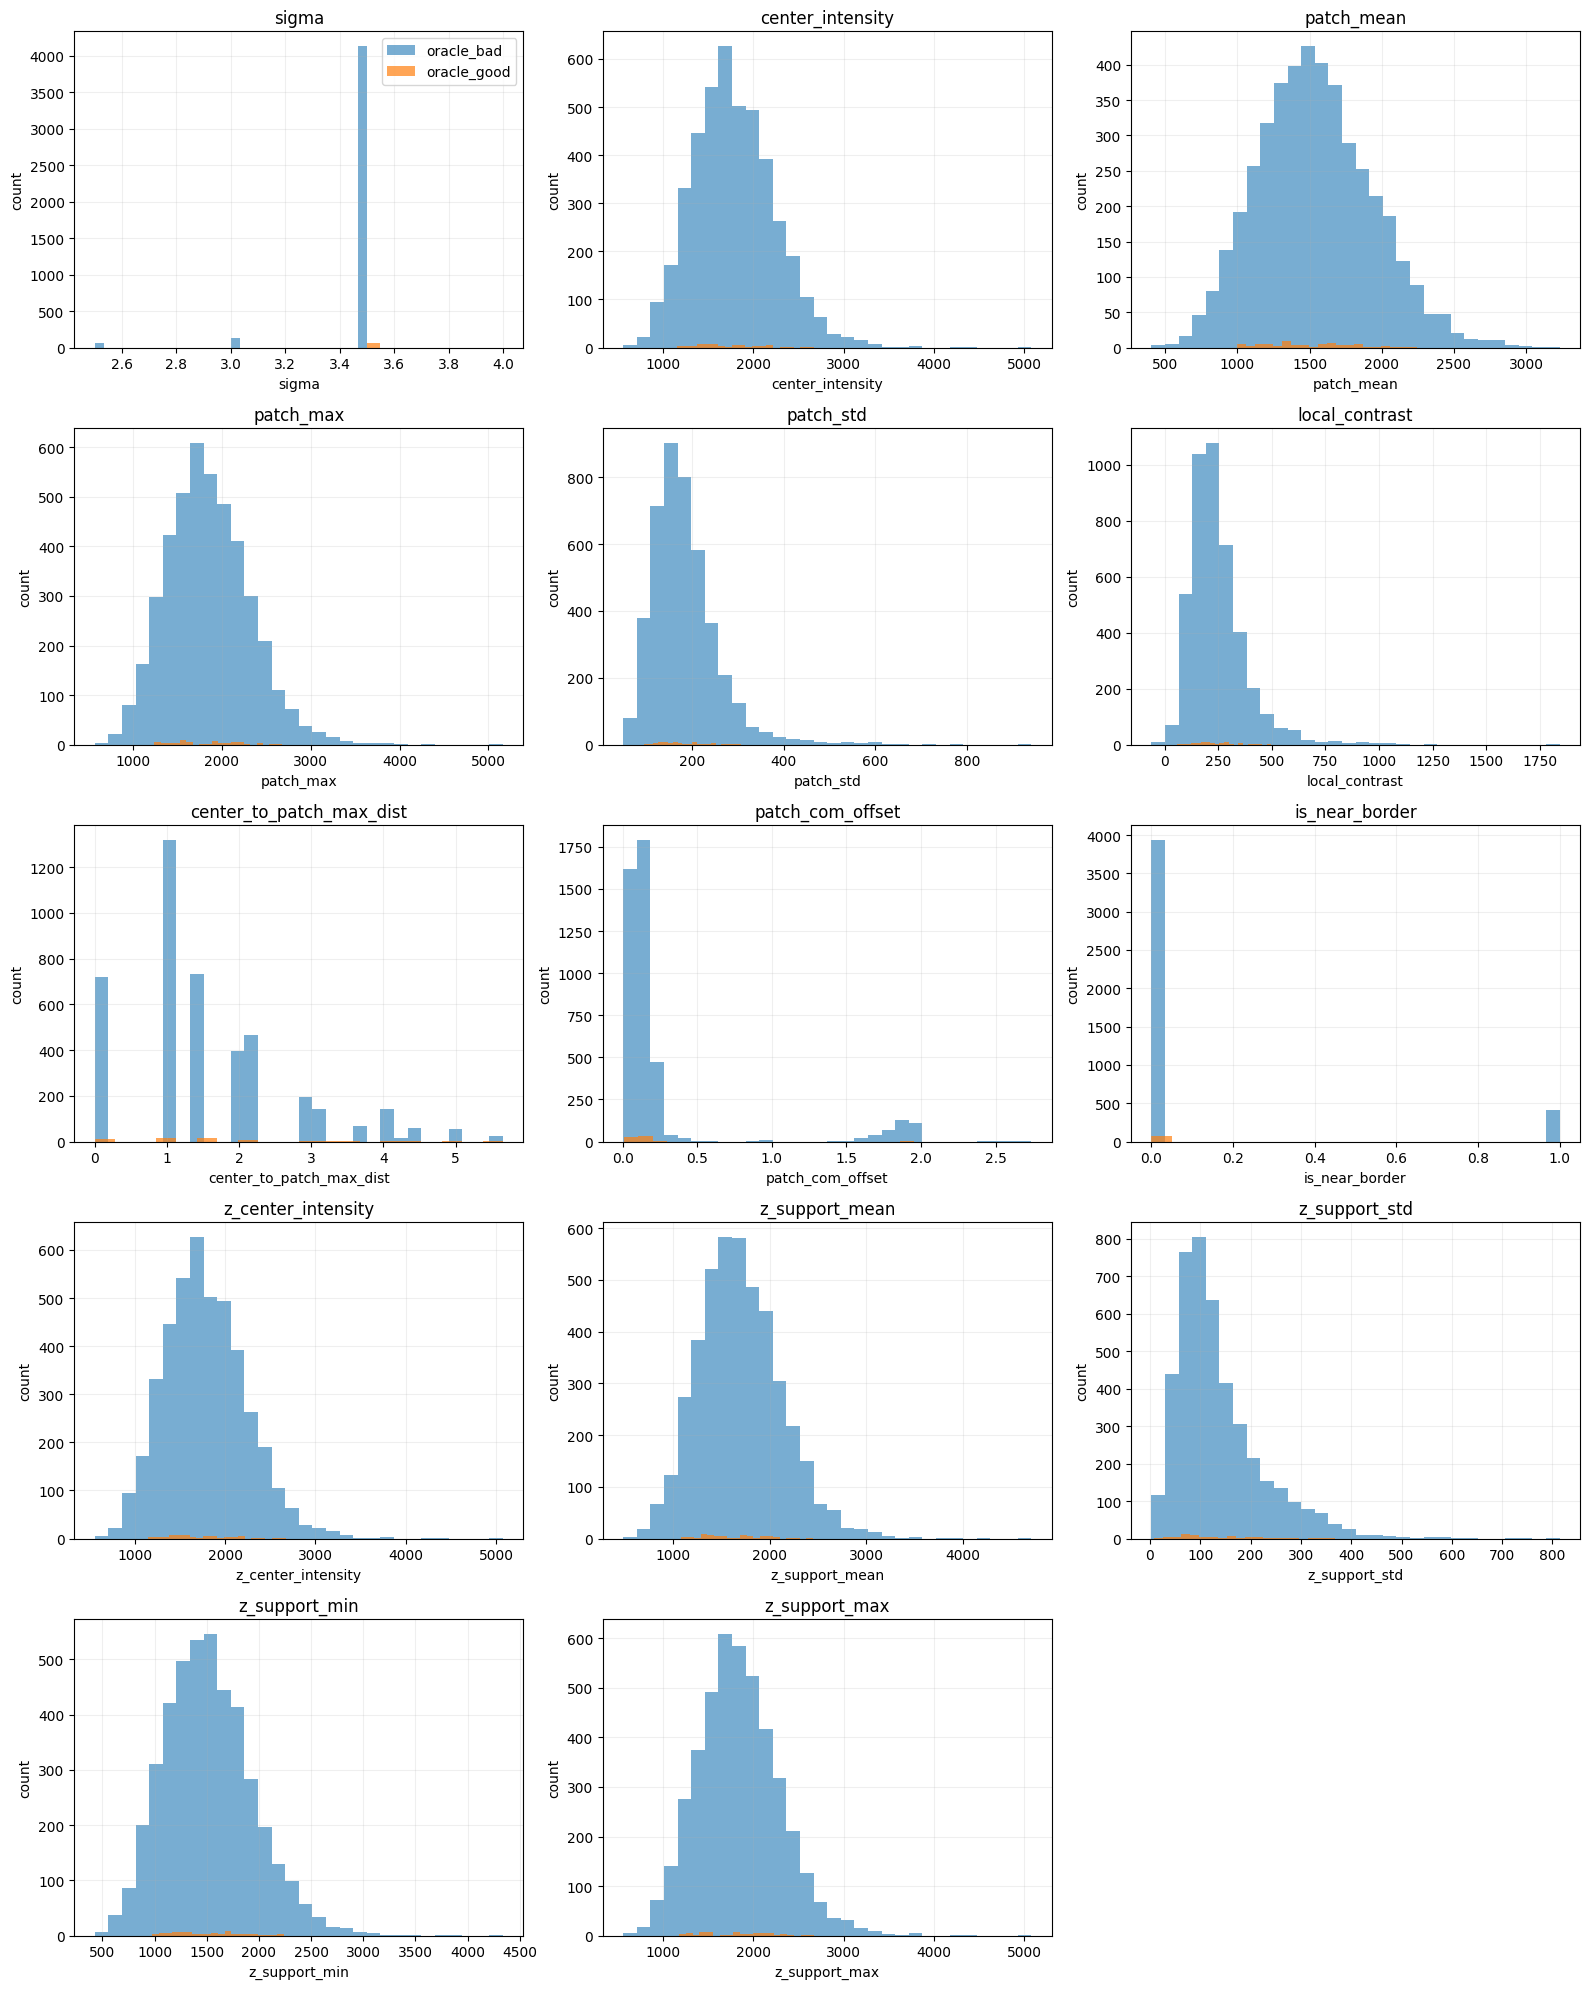

In [17]:
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.ravel()

for ax, feat in zip(axes, feature_cols):
    ax.hist(
        bad_df[feat].dropna(),
        bins=30,
        alpha=0.6,
        label="oracle_bad"
    )
    ax.hist(
        good_df[feat].dropna(),
        bins=20,
        alpha=0.7,
        label="oracle_good"
    )

    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.2)

axes[0].legend()

for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Step 9 — Plot Feature Values vs Nearest GT Distance

This shows whether top features change smoothly as candidates get farther from GT.

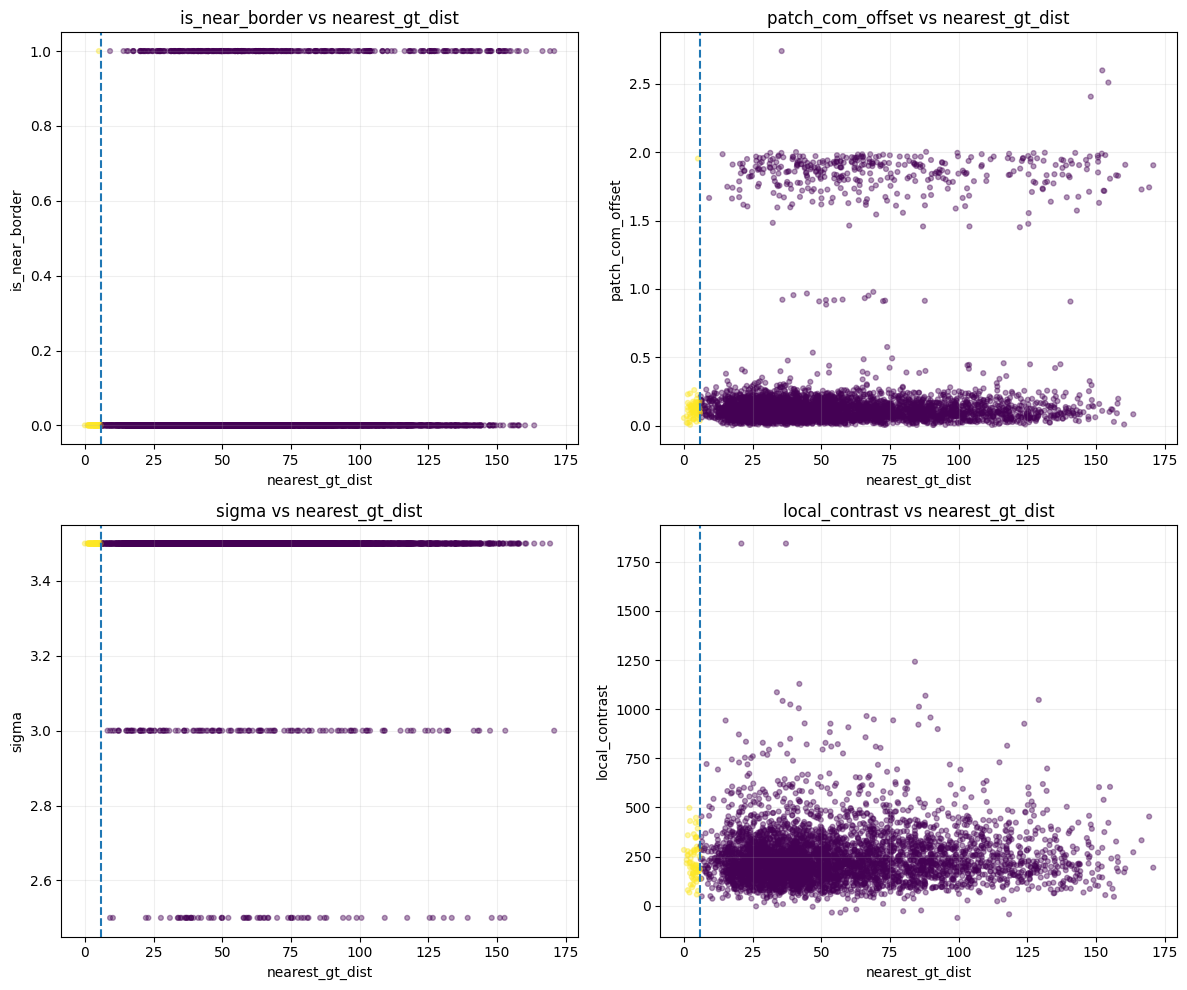

In [18]:
top_scatter_features = effect_df["feature"].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, feat in zip(axes, top_scatter_features):
    ax.scatter(
        candidate_df["nearest_gt_dist"],
        candidate_df[feat],
        c=candidate_df["oracle_good"].astype(int),
        alpha=0.4,
        s=12
    )

    ax.axvline(match_radius, linestyle="--")
    ax.set_title(f"{feat} vs nearest_gt_dist")
    ax.set_xlabel("nearest_gt_dist")
    ax.set_ylabel(feat)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Step 10 — Inspect Oracle-Good Candidates

This table shows whether oracle-good candidates are consistent or highly variable.

In [19]:
good_only_summary = good_df[feature_cols].agg(["mean", "median", "std", "min", "max"]).T
good_only_summary.sort_values("std", ascending=False)

,mean,median,std,min,max
z_support_max,1789.441176,1799.000000,382.381672,1178.000000,2672.000000
center_intensity,1735.294118,1657.500000,369.406747,1149.000000,2672.000000
z_center_intensity,1735.294118,1657.500000,369.406747,1149.000000,2672.000000
patch_max,1795.720588,1754.500000,365.589642,1238.000000,2678.000000
z_support_mean,1648.539216,1583.500000,345.156340,1084.333333,2447.000000
z_support_min,1477.205882,1410.500000,323.074482,975.000000,2240.000000
patch_mean,1508.469068,1474.024719,305.750975,994.530884,2246.901123
local_contrast,226.825050,205.129639,97.813883,56.580200,497.283936
z_support_std,133.150986,103.765638,84.822151,8.178563,368.630197
patch_std,175.952758,162.525970,49.033694,93.768433,305.424530


# Step 11 — Inspect Oracle-Bad Candidates

In [20]:
bad_only_summary = bad_df[feature_cols].agg(["mean", "median", "std", "min", "max"]).T
bad_only_summary.sort_values("std", ascending=False)

,mean,median,std,min,max
patch_max,1846.486973,1808.000000,469.231997,568.000000,5164.000000
center_intensity,1785.118515,1748.000000,457.438673,557.000000,5076.000000
z_center_intensity,1785.118515,1748.000000,457.438673,557.000000,5076.000000
z_support_max,1836.871109,1806.000000,456.381484,557.000000,5076.000000
z_support_mean,1691.646684,1653.000000,430.269985,486.000000,4707.000000
z_support_min,1519.321881,1487.000000,425.987076,428.000000,4338.000000
patch_mean,1540.043300,1515.567871,396.798792,403.753082,3232.666748
local_contrast,245.075215,218.622192,136.429001,-62.311157,1843.333252
z_support_std,135.442999,112.399091,86.616606,3.000000,814.248256
patch_std,183.437087,170.823273,75.753826,48.918777,940.442749


# Step 12 — Inspect Hard Oracle-Good Candidates

These are positive candidates that are closest to the edge of the match radius.
They may be harder for the model to learn.

In [21]:
hard_good_df = good_df.sort_values("nearest_gt_dist", ascending=False)

hard_good_df[
    ["t", "z", "y", "x", "nearest_gt_dist"] + top_features
].head(20)

,t,z,y,x,nearest_gt_dist,is_near_border,patch_com_offset,sigma,local_contrast,patch_max,center_intensity
2218,40,44,78,161,5.916080,0,0.108071,3.5,136.419800,2116.0,2029.0
2969,60,39,158,62,5.916080,0,0.122728,3.5,287.753052,2243.0,2143.0
3208,60,34,47,222,5.830952,0,0.093964,3.5,184.234619,1879.0,1805.0
811,8,44,120,143,5.744563,0,0.036428,3.5,295.123413,1911.0,1911.0
3388,60,33,145,145,5.656854,0,0.177221,3.5,251.185181,1428.0,1428.0
1120,8,36,48,187,5.477226,0,0.162857,3.5,135.691406,1570.0,1458.0
2823,60,47,66,164,5.477226,0,0.133704,3.5,423.555542,2442.0,2428.0
493,0,7,241,51,5.385165,0,0.083191,3.5,193.765381,1403.0,1364.0
279,0,41,204,94,5.385165,0,0.076757,3.5,172.370361,1658.0,1644.0
1805,20,8,234,60,5.196152,0,0.157849,3.5,182.456787,1608.0,1546.0


# Step 13 — Inspect Suspicious Oracle-Bad Candidates

These are oracle-bad candidates closest to GT. They may look like positives and confuse the model.

In [22]:
easy_bad_df = bad_df.sort_values("nearest_gt_dist")

easy_bad_df[
    ["t", "z", "y", "x", "nearest_gt_dist"] + top_features
].head(20)

,t,z,y,x,nearest_gt_dist,is_near_border,patch_com_offset,sigma,local_contrast,patch_max,center_intensity
2087,40,47,79,161,6.082763,0,0.102243,3.5,304.419678,2357.0,2357.0
1900,20,6,228,67,6.164414,0,0.214558,3.5,235.925903,1453.0,1382.0
1620,20,42,178,92,6.324555,0,0.186202,3.5,137.567871,1916.0,1779.0
1409,20,31,144,11,6.324555,0,0.186301,3.5,350.234619,2238.0,2206.0
679,8,42,123,142,6.403124,0,0.187130,3.5,454.481445,2476.0,2476.0
2663,40,2,233,58,6.403124,0,0.161115,3.5,188.358032,1218.0,1218.0
2478,40,31,153,35,6.480741,0,0.097565,3.5,47.209839,1813.0,1607.0
3792,80,44,72,178,6.557439,0,0.060064,3.5,283.185181,2271.0,2169.0
2103,40,45,79,158,6.633250,0,0.178379,3.5,325.209839,2296.0,2296.0
158,0,41,121,127,6.782330,0,0.142458,3.5,238.604980,1814.0,1808.0


# Step 14 — Build a Compact Feature Diagnosis Table

In [23]:
diagnosis_df = effect_df.copy()

diagnosis_df["direction_for_good"] = np.where(
    diagnosis_df["smd"] > 0,
    "higher in oracle_good",
    "lower in oracle_good"
)

diagnosis_df = diagnosis_df[
    ["feature", "mean_good", "mean_bad", "smd", "abs_smd", "direction_for_good"]
]

diagnosis_df

,feature,mean_good,mean_bad,smd,abs_smd,direction_for_good
8,is_near_border,0.014706,0.093844,-0.354336,0.354336,lower in oracle_good
7,patch_com_offset,0.141982,0.270015,-0.331346,0.331346,lower in oracle_good
0,sigma,3.500000,3.468296,0.296890,0.296890,higher in oracle_good
5,local_contrast,226.825050,245.075215,-0.153747,0.153747,lower in oracle_good
3,patch_max,1795.720588,1846.486973,-0.120696,0.120696,lower in oracle_good
1,center_intensity,1735.294118,1785.118515,-0.119840,0.119840,lower in oracle_good
9,z_center_intensity,1735.294118,1785.118515,-0.119840,0.119840,lower in oracle_good
4,patch_std,175.952758,183.437087,-0.117294,0.117294,lower in oracle_good
13,z_support_max,1789.441176,1836.871109,-0.112657,0.112657,lower in oracle_good
12,z_support_min,1477.205882,1519.321881,-0.111404,0.111404,lower in oracle_good


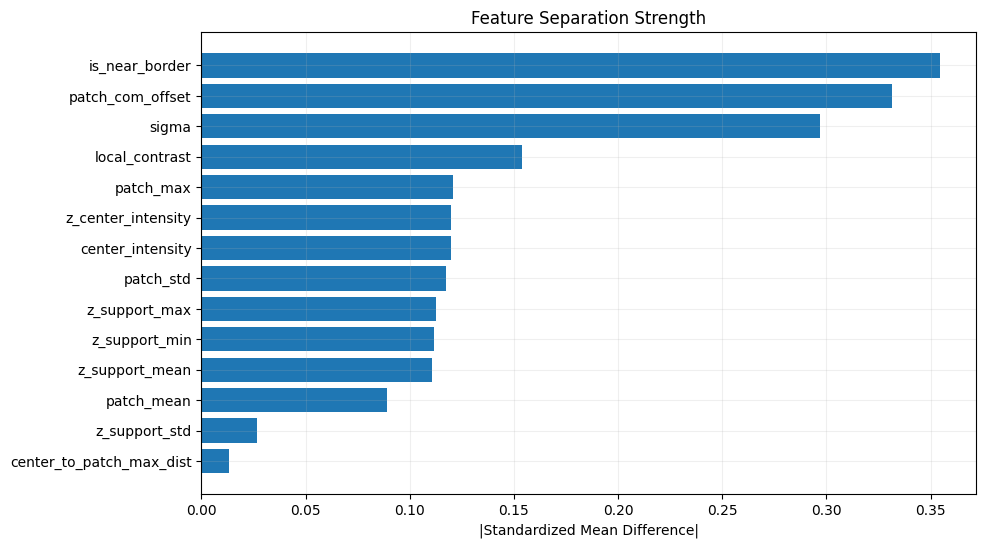

In [24]:
plt.figure(figsize=(10, 6))

plot_df = diagnosis_df.sort_values("abs_smd", ascending=True)

plt.barh(plot_df["feature"], plot_df["abs_smd"])
plt.title("Feature Separation Strength")
plt.xlabel("|Standardized Mean Difference|")
plt.grid(True, alpha=0.2)
plt.show()

# 📊 Results

The handcrafted features showed weak separation between oracle-good and oracle-bad candidates.

The strongest standardized mean differences were:

- `is_near_border`: 0.354
- `patch_com_offset`: 0.331
- `sigma`: 0.297
- `local_contrast`: 0.154

Most intensity and z-support features had much smaller separation values, generally around 0.10–0.12 or less.

The feature histograms showed substantial overlap between oracle-good and oracle-bad candidates.

# 🔍 Analysis

This chapter explains why the random forest rankers failed in Chapters 16–18.

The current features contain some signal, especially border status, patch center-of-mass offset, and sigma. However, the separation is too weak to reliably push oracle-good candidates into the top-ranked positions.

The model is not failing because there are no good candidates. It is failing because the current feature representation does not make good candidates distinct enough from visually similar bad candidates.